<a href="https://colab.research.google.com/github/cpython-projects/da_27_07_2026/blob/main/lesson_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лекція 15. Розподіли даних, стандартне відхилення, Z-score та IQR

**Навіщо це потрібно.** Форма розподілу визначає, які статистики й методи взагалі мають сенс: для симетричних "дзвіноподібних" даних працюють середнє, стандартне відхилення й правило 3σ; для скошених даних (а таких — більшість у реальному бізнесі: зарплати, ціни, час обробки) ці ж метрики вводять в оману, і потрібні медіана, IQR та лог-трансформація.

**План лекції:**

| Частина | Тема |
|---|---|
| 1 | Що таке розподіл |
| 2 | Теоретичні розподіли (нормальний, рівномірний, експоненційний, логнормальний, Парето, Пуассона, мультимодальний) |
| 3 | Реальні (емпіричні) приклади розподілів |
| 4 | Навіщо аналітику визначати тип розподілу |
| 5 | Стандартне відхилення, правило ±1σ/±2σ/±3σ, коефіцієнт варіації |
| 6 | Z-score та пошук аномалій |
| 7 | Квантилі, квартилі, IQR та пошук викидів — практика на реальних даних |

# 1. Що таке розподіл?

**Розподіл** — це спосіб описати, як значення певної змінної «розкидані» у вибірці. Він показує, з якою частотою зустрічаються різні значення.

Наприклад, якщо у нас є дані про вік студентів, то можна побудувати гістограму, щоб побачити розподіл.

<Axes: >

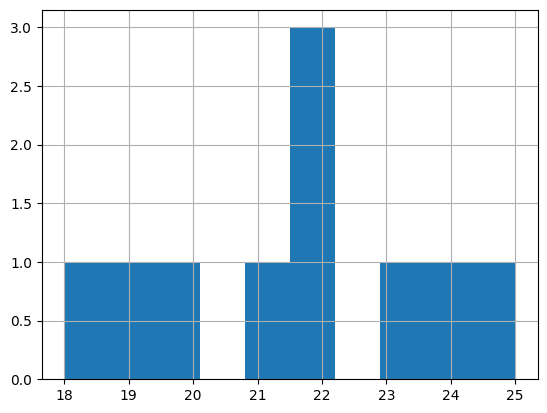

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


ages = pd.Series([18, 19, 20, 21, 22, 22, 22, 23, 24, 25])
ages.hist(bins=10)

На гістограмі видно, що вік студентів зосереджений навколо **22 років** (це значення трапляється тричі — найчастіше), а до країв (18 і 25) значення трапляються рідше. Це і є "форма" розподілу для цієї конкретної колонки.

Розподіл — це відповідь на питання:

> Які значення в стовпці трапляються частіше, які рідше, і як вони «розподілені» вздовж числової осі?

Розподіл — це **структура даних**:

* чи є перекіс?
* чи є рідкісні екстремальні значення?
* чи є кілька груп?
* де знаходиться «центр» даних?

Від форми розподілу залежить:

* які метрики використовувати,
* які моделі застосовувати,
* які тести є коректними,
* як очищати викиди,
* як нормувати дані.

# 2. Які бувають розподіли?

## Модельні (теоретичні)

Це розподіли з відомою математичною формулою. Далі — кілька найпоширеніших, кожен згенерований штучно (`numpy.random`), щоб побачити його характерну форму.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Нормальний (дзвінкоподібна крива) — **Normal (bell-shaped curve)**

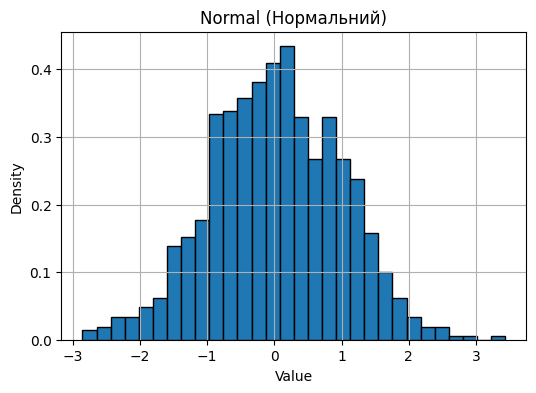

In [2]:
# Нормальний розподіл
data = np.random.normal(loc=0, scale=1, size=1000)

plt.figure(figsize=(6, 4))
plt.hist(data, bins=30, density=True, edgecolor='black')
plt.title("Normal (Нормальний)")
plt.xlabel("Value")
plt.ylabel("Density")
plt.grid(True)
plt.show()

* **Форма:** симетрична дзвінкоподібна (bell curve).
* **Характеристики:** середнє = медіана = мода; більшість значень — біля центру.
* **Де використовується:** зріст людей, IQ, похибки вимірювань, природні процеси.
* **Базовий стандарт.** Часто використовується як "еталон" для порівняння.

### Рівномірний — **Uniform**

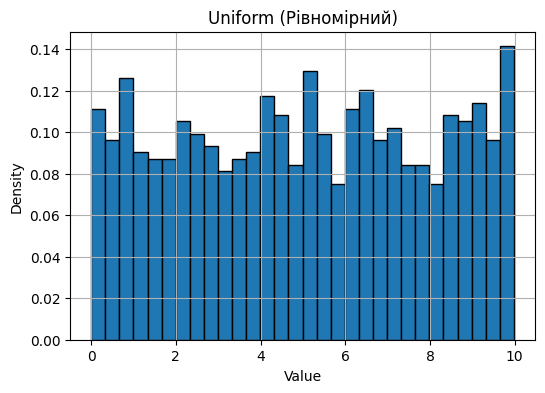

In [3]:
data = np.random.uniform(low=0, high=10, size=1000)

plt.figure(figsize=(6, 4))
plt.hist(data, bins=30, density=True, edgecolor='black')
plt.title("Uniform (Рівномірний)")
plt.xlabel("Value")
plt.ylabel("Density")
plt.grid(True)
plt.show()

* **Форма:** прямокутник — усі значення мають однакову ймовірність.
* **Характеристики:** немає переважних значень; повна "невизначеність".
* **Де використовується:** генерація випадкових чисел, первинні гіпотези, випадкові події.
* **Найпростіший розподіл**, використовується як базовий при симуляціях.

### Експоненційний — **Exponential**

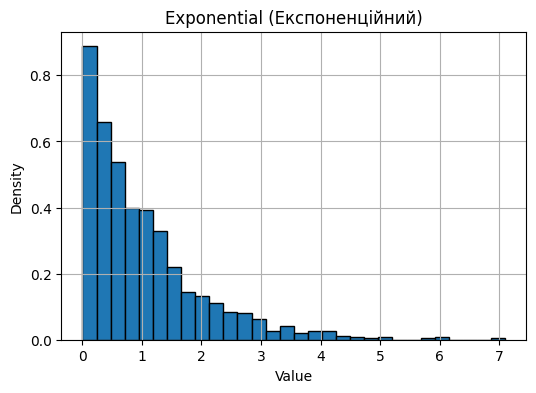

In [4]:
data = np.random.exponential(scale=1.0, size=1000)

plt.figure(figsize=(6, 4))
plt.hist(data, bins=30, density=True, edgecolor='black')
plt.title("Exponential (Експоненційний)")
plt.xlabel("Value")
plt.ylabel("Density")
plt.grid(True)
plt.show()

* **Форма:** правосторонньо скошена (right-skewed), максимум у 0, далі швидко спадає.
* **Характеристики:** ймовірність події зменшується з часом.
* **Де використовується:** час до настання наступної події — наприклад, час до розриву деталі або між дзвінками.

### Логнормальний — **Log-normal**

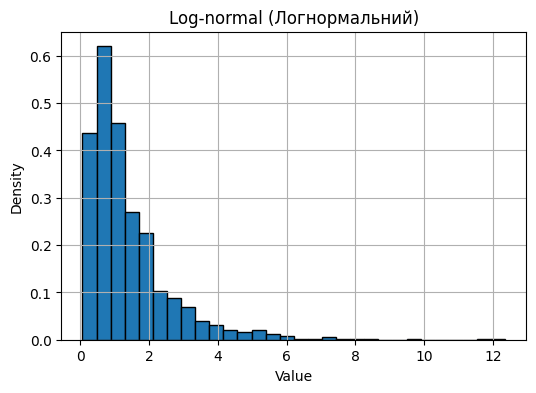

In [5]:
data = np.random.lognormal(mean=0, sigma=0.8, size=1000)

plt.figure(figsize=(6, 4))
plt.hist(data, bins=30, density=True, edgecolor='black')
plt.title("Log-normal (Логнормальний)")
plt.xlabel("Value")
plt.ylabel("Density")
plt.grid(True)
plt.show()

* **Форма:** правосторонньо скошена, як «розтягнутий» нормальний розподіл.
* **Характеристики:** логарифм значень має нормальний розподіл.
* **Де використовується:** час виконання задач, доходи, розмір файлів, тривалість проєктів.
* **Візуально схожа на експоненціальний**, але максимум далі від нуля.

**логарифм значень має нормальний розподіл** — це ключова властивість логнормального розподілу:

> Якщо взяти всі значення, застосувати до них логарифм, то отримані числа будуть розподілені **нормально** (як «дзвін»).

Тобто самі значення — **НЕ** нормальні,
але їхні логарифми — нормальні.

---

### Чому так відбувається?

Логарифм — це операція, яка «стискає» великі значення і «розтягує» малі.

Наприклад:

| Значення | Логарифм |
| -------- | -------- |
| 1        | 0        |
| 10       | 2.30     |
| 100      | 4.60     |
| 1000     | 6.90     |

Великий розкид перетворюється на акуратний діапазон.

І якщо в початкових даних **величезний розкид**, але діють **мультиплікативні фактори** (множення), то після логарифмування вони перетворюються на «плюс-мінус симетричні» дані → нормальний розподіл.

---

### Чому логнормальний розподіл трапляється часто?

Тому що в реальному житті багато процесів влаштовані **мультиплікативно**, а не адитивно.

Приклади:

* доходи людей (зростають у %)
* ціни акцій
* час виконання (якщо одна затримка множить термін)
* тривалість сесій в інтернеті
* перегляди, лайки, продажі
* розміри файлів

Перевіримо це на практиці: візьмемо ті самі логнормальні дані (`data` з попередньої комірки) і прологарифмуємо їх.

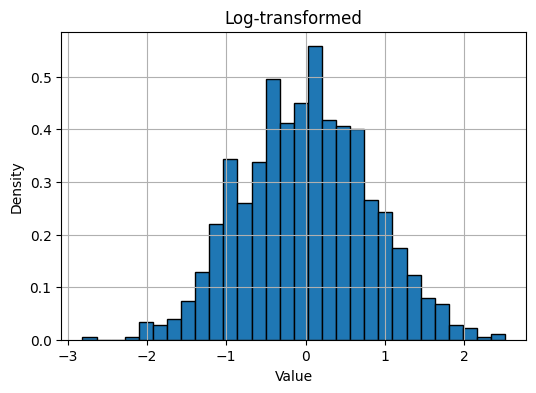

In [6]:
# data - це логнормальна вибірка, згенерована двома комірками вище
data_log_x = np.log(data)  # якщо нулі відсутні

# якщо є нулі
# data_log_x = np.log1p(data)  # log(1+x)

plt.figure(figsize=(6, 4))
plt.hist(data_log_x, bins=30, density=True, edgecolor='black')
plt.title("Log-transformed")
plt.xlabel("Value")
plt.ylabel("Density")
plt.grid(True)
plt.show()

Ми застосували **натуральний логарифм** до логнормально розподілених даних, щоб:

* прибрати сильну асиметрію,
* зробити розподіл близьким до нормального,
* коректно застосовувати статистичні методи.

---

## Як інтерпретувати результати після логарифмування

In [7]:
# Середнє в log-шкалі

mu = data_log_x.mean()
print(mu)

0.012249489656982377


In [8]:
# У вихідній шкалі це інтерпретується як **геометричне середнє**:
geo_mean = np.exp(mu)
print(geo_mean)

1.0123248219351528


In [9]:
# Стандартне відхилення в log-шкалі
sigma = data_log_x.std()
print(sigma)

0.8032771274630877


In [10]:
# Це не стандартне відхилення в одиницях змінної, а мультиплікативний розкид.
factor = np.exp(sigma)
print(factor)

2.232846273524855


In [11]:
# Інтервал "типових значень"

lower = geo_mean / factor
upper = geo_mean * factor

print(lower, upper)

0.45337864676955963 2.2603657062546185


> 💡 **Забігаючи наперед:** ділення/множення на `factor` (тобто на $e^\sigma$) тут — це той самий принцип, що й "±1σ" для звичайного нормального розподілу (розділ 5 нижче): там ми **додаємо/віднімаємо** σ, тут — **ділимо/множимо** на мультиплікативний аналог σ, бо працюємо в логарифмічній шкалі. І так само, як ±1σ покриває 68% нормальних даних, цей інтервал [geo_mean/factor, geo_mean*factor] покриває приблизно ту саму частку (68%) логнормальних даних — просто в мультиплікативному, а не адитивному вигляді.

## Головна ідея

> **У log-шкалі ми рахуємо статистику.
> У вихідній шкалі ми інтерпретуємо результат через множники та відсотки.**

* середнє → **типове значення**
* стандартне відхилення → **у скільки разів коливаються дані**
* різниця середніх → **відсоткова зміна**

### Парето - **Pareto**

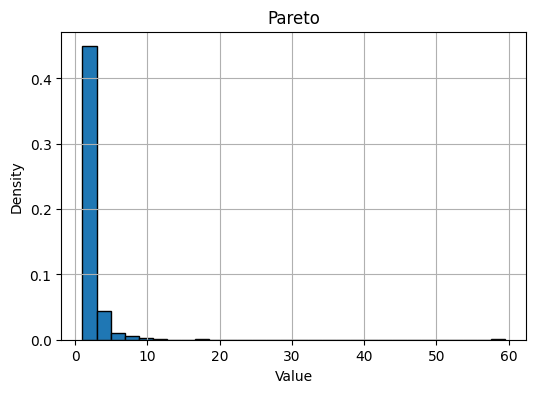

In [12]:
np.random.seed(42)
data = (np.random.pareto(a=2, size=1000) + 1) * 1  # зсув, щоб min=1

plt.figure(figsize=(6, 4))
plt.hist(data, bins=30, density=True, edgecolor='black')
plt.title("Pareto")
plt.xlabel("Value")
plt.ylabel("Density")
plt.grid(True)
plt.show()

* **Форма:** сильно скошене вправо, «довгий хвіст» — мало великих значень, багато малих.
* **Характеристики:** правило 80/20 — більша частина ефекту (доходів, ресурсів, продажів) створюється невеликою часткою елементів.
* **Де використовується:** моделювання доходів, багатства, розмірів міст, розмірів файлів, ризиків великих втрат.
* **Особливість:** розподіл із «важким хвостом», екстремальні значення трапляються значно частіше, ніж у нормальному або рівномірному розподілі.

### Правосторонньо асиметричний або зі скошеністю вправо — **Right-skewed**

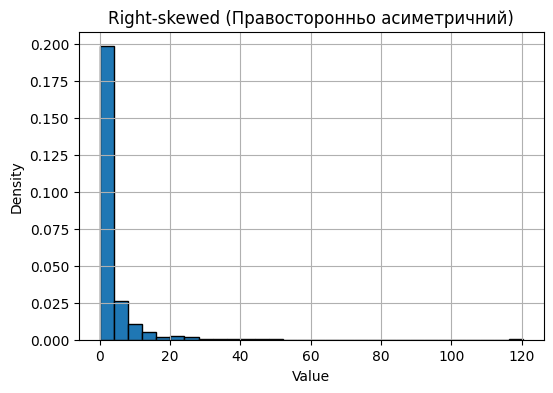

In [13]:
data = np.random.lognormal(mean=0, sigma=1.5, size=1000)

plt.figure(figsize=(6, 4))
plt.hist(data, bins=30, density=True, edgecolor='black')
plt.title("Right-skewed (Правосторонньо асиметричний)")
plt.xlabel("Value")
plt.ylabel("Density")
plt.grid(True)
plt.show()

* **Форма:** будь-який розподіл, у якого хвіст справа довший.
* **Це не конкретний розподіл**, а **властивість** форми.
* **До таких відносяться:** експоненціальний, логнормальний, Парето.
* **У реальному світі більшість «позитивних» величин (тривалість, доходи) саме такі.**

### Пуассонівський — **Poisson**

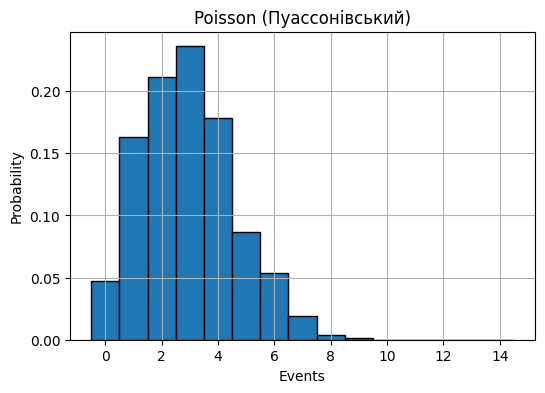

In [14]:
data = np.random.poisson(lam=3, size=1000)

plt.figure(figsize=(6, 4))
plt.hist(data, bins=np.arange(-0.5, 15.5, 1), density=True, edgecolor='black')
plt.title("Poisson (Пуассонівський)")
plt.xlabel("Events")
plt.ylabel("Probability")
plt.grid(True)
plt.show()

* **Форма:** дискретна, схожа на скошений нормальний розподіл.
* **Характеристики:** моделює **кількість подій** за фіксований проміжок часу або простору.
* **Де використовується:** моделює кількість подій за фіксований проміжок часу, коли події відбуваються незалежно одна від одної: кількість звернень у кол-центр за годину; кількість покупок за хвилину (якщо потік «розріджений»); кількість ДТП за день на ділянці дороги; кількість відвідувань сайту за секунду (у low-traffic).

### Мультимодальний (тобто розподіл із кількома вершинами/піками) — **Multimodal**

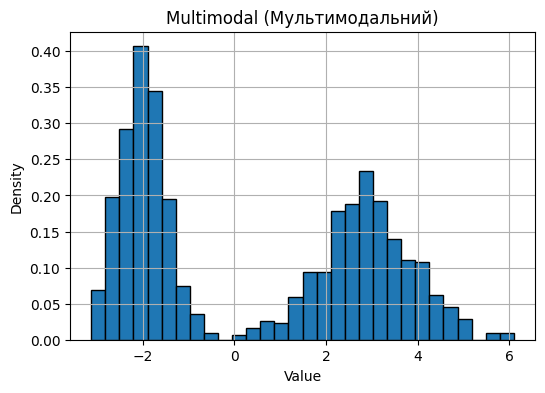

In [15]:
data1 = np.random.normal(loc=-2, scale=0.5, size=500)
data2 = np.random.normal(loc=3, scale=1.0, size=500)
data = np.concatenate([data1, data2])

plt.figure(figsize=(6, 4))
plt.hist(data, bins=30, density=True, edgecolor='black')
plt.title("Multimodal (Мультимодальний)")
plt.xlabel("Value")
plt.ylabel("Density")
plt.grid(True)
plt.show()

* **Форма:** має кілька піків (мод) замість одного.
* **Характеристики:** свідчить про **змішаність груп у даних**.
* **Де використовується:** розподіл зарплат у компанії з кількома посадами, результати різних кластерів.
* **Може ввести в оману**, якщо очікувався один "тип" поведінки в даних.

## Реальні (емпіричні)

> 💡 Три приклади нижче (зарплати, оцінки, покупки) — це **змодельовані, штучно згенеровані** дані (`np.random...`), які ілюструють типову *форму*, яку такі величини мають у реальному житті. Це навчальні приклади, а не виміряні дані. Наприкінці лекції (розділ 7) ми проведемо той самий аналіз на **справді реальних** даних — фактичних продажах житла (`kc_house_data.csv`).

### Зарплати в ІТ — часто **зміщений вправо** (довгий «хвіст» з великими значеннями)

👉 Основна маса зарплат — у межах 1000–4000 \$, але є топ-менеджери з 10k–20k+

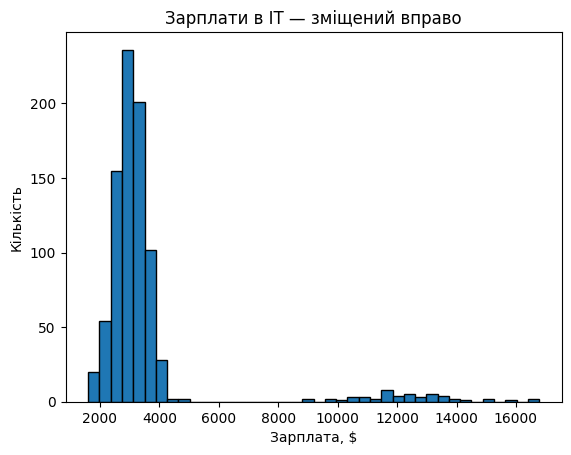

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

# Більшість зарплат — середні
middle = np.random.normal(3000, 500, 800)

# Топи — менші, але значно більші значення
high = np.random.normal(12000, 2000, 50)

# Об'єднання і візуалізація
salaries = np.concatenate([middle, high])

plt.hist(salaries, bins=40, edgecolor='black')
plt.title("Зарплати в ІТ — зміщений вправо")
plt.xlabel("Зарплата, $")
plt.ylabel("Кількість")
plt.show()

**Що бачимо**:

* Основна маса зліва
* Довгий «хвіст» праворуч
* Середнє не показує «типову» зарплату → краще дивитися на **медіану** або **Q1–Q3**

### Оцінки студентів — часто **трапецієподібний**

👉 Часто оцінки «склеюються» вгорі: більшість студентів отримують 4–5

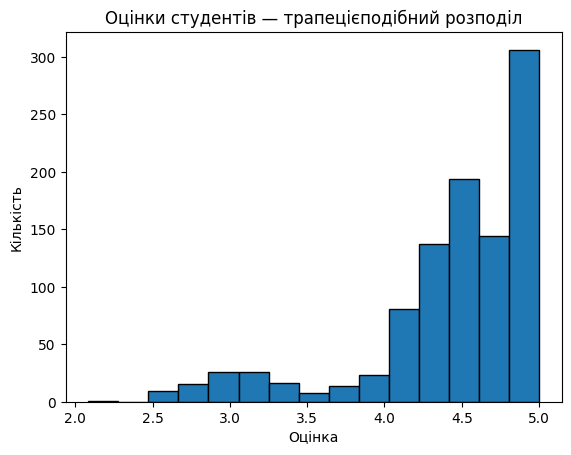

In [ ]:
grades = np.concatenate([
    np.random.normal(3, 0.3, 100),    # частина слабших
    np.random.normal(4.5, 0.3, 700),  # більшість
    np.random.normal(5, 0.1, 200)     # відмінники
])

grades = np.clip(grades, 2, 5)  # обмежуємо до 5-бальної шкали

plt.hist(grades, bins=15, edgecolor='black')
plt.title("Оцінки студентів — трапецієподібний розподіл")
plt.xlabel("Оцінка")
plt.ylabel("Кількість")
plt.show()

**Що бачимо**:

* Дані скупчені ближче до 4–5
* Може бути плато → **трапеція**
* У таких випадках середнє **майже не змінюється**, але краще дивитись на **Q1, Q3**, або будувати **boxplot**

### Кількість покупок клієнта — **розріджений**, часто **експоненційний** або **з нульовим модусом**

👉 Більшість клієнтів купують 0–1 раз, меншість — 10+

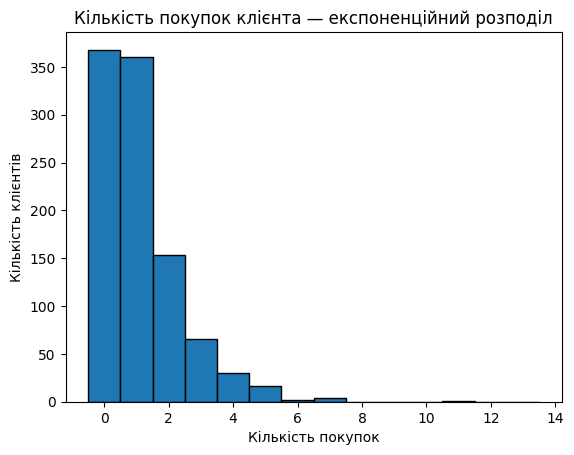

In [ ]:
purchases = np.random.exponential(scale=1.2, size=1000)
purchases = np.round(purchases)

plt.hist(purchases, bins=range(0, 15), align='left', edgecolor='black')
plt.title("Кількість покупок клієнта — експоненційний розподіл")
plt.xlabel("Кількість покупок")
plt.ylabel("Кількість клієнтів")
plt.show()

**Що бачимо**:

* Дуже багато клієнтів купили **0 або 1 раз**
* Хвіст довгий, але **частота різко спадає**
* Середнє не репрезентативне → краще рахувати **конверсію**, **медіану**, або **побудувати частоти на кластери**

# 3. Навіщо аналітику визначати розподіл даних по стовпцю?

## **1. Вибір коректних статистичних методів**

Різні розподіли потребують різних підходів:

* **Нормальний розподіл** → можна використовувати середнє, стандартне відхилення, t-тести, кореляції Пірсона.
* **Скошений розподіл** → середнє вже вводить в оману → краще використовувати медіану, IQR, рангові тести, лог-трансформацію.
* **Мультимодальний** → вказує на наявність різних груп всередині даних → перед моделюванням їх потрібно розділити.

**Якщо не знаєш розподіл — можеш обрати неправильний метод і отримати хибні висновки.**

---

## **2. Розуміння природи та поведінки даних**

Розподіл показує характер явища:

* Чи є **пороговий ефект**?
* Чи є **рідкісні, екстремальні події** (heavy tails)?
* Значення розподілені рівномірно чи є кластери?

Наприклад: продажі, час обробки заявок, доходи — майже завжди **право-скошені**. Це нормальна логіка бізнесу, і аналітик повинен її розуміти.

---

## **3. Виявлення викидів**

Викиди можуть бути:

* помилками введення (200 років вік клієнта),
* природними екстремальними значеннями (VIP-клієнти),
* або маркерами аномалій для детектування.

Але ти можеш побачити викиди **тільки**, якщо розумієш форму розподілу.

---

## **4. Коректна візуалізація**

# 4. Чи достатньо тільки візуалізації для визначення типу розподілу?

**Ні, не завжди.**

**Візуалізації достатньо у двох випадках:**

* явна нормальність/сильна скошеність/бімодальність видно неозброєним оком;
* розподіл чистий і вибірка велика.

**Візуалізації НЕ достатньо, якщо:**

* мало даних — гістограма буде вводити в оману;
* є важкі «хвости», непомітні на звичних масштабах;
* потрібне формальне статистичне обґрунтування.

# 5. Що таке стандартне відхилення?

**Стандартне відхилення** — це **середня відстань** значень від середнього.

* Якщо значення «тримаються купою» навколо середнього — відхилення маленьке.
* Якщо багато значень сильно відрізняються — велике.

---

**Формула**

$$
\sigma = \sqrt{ \frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})^2 }
$$

* n – кількість значень у наборі даних (розмір вибірки)
* xᵢ – i-й елемент набору даних
* $\bar{x}$ – середнє арифметичне всіх $x_i$

---

**Стандартне відхилення:**

* показує **розкид** значень
* дозволяє будувати **довірчі інтервали** (діапазон, у якому з певною ймовірністю знаходиться істинне середнє генеральної сукупності)
* критично для **нормального розподілу**

⚠️ **Усе це — тільки якщо дані приблизно нормально розподілені!**

---

**Коли на нього дивитися:**

| Ситуація                               | Чи варто дивитися на std?     |
| --------------------------------------- | ------------------------------ |
| Дані нормально розподілені             | ✅ Так, повна сила std         |
| Дані приблизно симетричні, без викидів | ✅ Можна використовувати       |
| Є зміщення або асиметрія               | ⚠️ Обережно                   |
| Є викиди або «важкий хвіст»            | ❌ Середнє та std нерелевантні |

## Що означає ±1σ, ±2σ, ±3σ?

Це **інтервали навколо середнього**, які у нормальному розподілі мають особливе значення:

| Інтервал             | Скільки даних всередині (≈) |
| --------------------- | ----------------------------- |
| **[μ − 1σ, μ + 1σ]** | ~68% значень                  |
| **[μ − 2σ, μ + 2σ]** | ~95% значень                  |
| **[μ − 3σ, μ + 3σ]** | ~99.7% значень                |

🔔 Працює **тільки для нормального розподілу!**

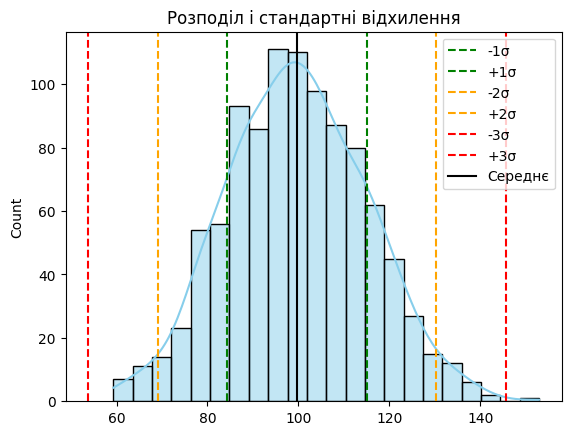

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = np.random.normal(100, 15, 1000)

sns.histplot(data, kde=True, color='skyblue')
mean = np.mean(data)
std = np.std(data)

for i, color in zip([1, 2, 3], ['green', 'orange', 'red']):
    plt.axvline(mean - i*std, linestyle='--', color=color, label=f'-{i}σ')
    plt.axvline(mean + i*std, linestyle='--', color=color, label=f'+{i}σ')

plt.axvline(mean, color='black', label='Середнє')
plt.legend()
plt.title("Розподіл і стандартні відхилення")
plt.show()

На графіку добре видно: майже всі значення потрапляють у межі ±2σ (зелена й оранжева лінії), а за межі ±3σ (червона лінія) виходять лічені точки — це і є правило 68-95-99.7 наочно, саме тому що дані тут згенеровані як строго нормальні (`np.random.normal`). Для реальних скошених даних (як ми побачимо нижче на прикладі цін на житло) ці межі так акуратно не працюють.

> ⚠️ **На що звернути увагу: "популяційне" vs "вибіркове" σ.** Формула вище ділить на $n$ — це **популяційне** стандартне відхилення (припускаємо, що маємо дані про *всю* сукупність). Але `pandas` (`df.col.std()`) і `statistics.stdev()` за замовчуванням рахують **вибіркове** відхилення — діляться на $(n-1)$, а не на $n$ (поправка Бесселя), бо на практиці майже завжди маємо лише *вибірку* з ширшої генеральної сукупності. `numpy.std()`, навпаки, за замовчуванням рахує популяційне ($n$), як у формулі.
>
> Для великих вибірок (тисячі спостережень, як наш `kc_house_data`) різниця мізерна. Але на малих вибірках (наприклад, наш приклад з 7 значень для Z-score нижче) вона вже помітна — тому важливо знати, яку саме формулу рахує ваша функція.

In [ ]:
import numpy as np
import statistics

sample = [10, 12, 14, 15, 16, 17, 20]

print('numpy.std (популяційне, ddof=0):   ', np.std(sample))
print('numpy.std (вибіркове,  ddof=1):    ', np.std(sample, ddof=1))
print('statistics.stdev (вибіркове):      ', statistics.stdev(sample))
print('statistics.pstdev (популяційне):   ', statistics.pstdev(sample))
print('pandas .std() (вибіркове за замовч.):', pd.Series(sample).std())

numpy.std (популяційне, ddof=0):    3.0438965360946453
numpy.std (вибіркове,  ddof=1):     3.2877840272018797
statistics.stdev (вибіркове):       3.2877840272018797
statistics.pstdev (популяційне):    3.0438965360946453
pandas .std() (вибіркове за замовч.): 3.2877840272018797


На 7 значеннях різниця між популяційним (≈3.04) і вибірковим (≈3.29) σ вже помітна — близько 8%. Правило: якщо працюєте із `pandas`, за замовчуванням отримуєте вибіркове σ; якщо з "голим" `numpy` — популяційне. Завжди перевіряйте, яке саме вам потрібне (і який `ddof` використовує функція), особливо на невеликих вибірках.

## **Коефіцієнт варіації (Coefficient of Variation, CV)** — це **відносна міра розкиду даних**, яка показує, наскільки сильно варіюються значення відносно свого середнього.

Його часто називають *«нормалізованим стандартним відхиленням»*.

---

### **Формула**

$$
CV = \frac{\sigma}{\bar{x}}
$$

* Зазвичай виражають у відсотках:

$$
CV = \frac{\sigma}{\bar{x}} \cdot 100\%
$$

---

### **Інтерпретація**

Коефіцієнт варіації показує:

> **яка частка середнього становить стандартне відхилення.**

Приклад:
Якщо CV = 0.25 → це означає, що розкид становить 25% від середнього.

---

### **Коли CV корисний?**

**1. Порівняння розкиду різних показників**

Якщо два показники мають різні шкали, їх SD порівнювати не можна, а CV — можна.

Приклад:

* коливання цін на золото (у доларах)
* коливання курсу валют (у відсотках)
  CV дозволяє порівнювати стабільність різних ринків.

**2. Аналіз якості вимірювань**

* Високий CV → низька стабільність.
* Низький CV → вимірювання точні та повторювані.

**3. В аналізі продажів, попиту, ризиків**

* низький CV → показник стабільний;
* високий CV → поведінка непередбачувана.

---

### **Коли CV НЕ варто використовувати**

1. **Якщо середнє близьке до нуля**
   CV починає «вибухати» і стає безглуздим.

2. **Якщо середнє від'ємне**
   CV втрачає сенс.

3. **Для розподілів, де середнє погано характеризує центр**
   Наприклад, важкі хвости.

# 6. Що таке Z-score?

**Z-score (стандартне відхилення)** показує, **на скільки σ (стандартних відхилень)** елемент відрізняється від середнього значення.

$$
Z = \frac{x - \mu}{\sigma}
$$

* $x$ — значення,
* $\mu$ — середнє значення (mean),
* $\sigma$ — стандартне відхилення (standard deviation)

---

## Як інтерпретувати Z-score:

| Z-score      | Інтерпретація                                                    |
| ------------- | ------------------------------------------------------------------ |
| ≈ 0          | Значення близьке до середнього                                   |
| > 1 або < -1 | Далеко від середнього                                             |
| > 2 або < -2 | Можлива аномалія                                                  |
| > 3 або < -3 | Ймовірна аномалія (у нормальному розподілі таких значень <0.3%) |

In [18]:
from scipy.stats import zscore
import statistics

x = [10, 12, 14, 15, 16, 17, 300]
z = zscore(x)

print(statistics.mean(x))
print(x)
print(z)

54.857142857142854
[10, 12, 14, 15, 16, 17, 300]
[-0.44810801 -0.42812868 -0.40814934 -0.39815967 -0.38817    -0.37818033
  2.44889602]


In [19]:
for xi, zi in zip(x, z):
    print(f"x = {xi}, z = {zi:.2f}")

x = 10, z = -0.45
x = 12, z = -0.43
x = 14, z = -0.41
x = 15, z = -0.40
x = 16, z = -0.39
x = 17, z = -0.38
x = 300, z = 2.45


Найбільше значення (`300`) отримало Z-score **≈ 2.45** — за таблицею вище це потрапляє в зону **"можлива аномалія"** (`|Z| > 2`), але ще не сягає порогу **"ймовірна аномалія"** (`|Z| > 3`). Це нормально: одне екстремальне значення серед лише 7 спостережень сильно "тягне" середнє й σ на себе (адже і середнє, і σ рахуються по цій же вибірці, включно з викидом) — тому сам викид виглядає "не таким уже й далеким" у σ-одиницях. Це — відома слабкість Z-score, детальніше нижче.

Подивимось, що станеться, якщо викид буде ще більш екстремальним.

In [ ]:
x2 = [10, 12, 14, 15, 16, 17, 1000]
z2 = zscore(x2)

for xi, zi in zip(x2, z2):
    print(f"x = {xi}, z = {zi:.2f}")

x = 10, z = -0.42
x = 12, z = -0.41
x = 14, z = -0.41
x = 15, z = -0.41
x = 16, z = -0.40
x = 17, z = -0.40
x = 1000, z = 2.45


Тепер викид `1000` дає `Z ≈ 2.45` знову — і це не помилка, а та сама слабкість: чим екстремальніший викид, тим сильніше він «роздуває» саме стандартне відхилення, тому його власний Z-score майже не зростає. Це називають **ефектом маскування** (masking effect): один потужний викид ховає сам себе, спотворюючи статистики, якими ми ж намагаємось його виявити.

Ті значення, де $|z| > 3$, — кандидати на викиди. Але, як щойно побачили, на малих вибірках з одним сильним викидом сам Z-score може не перетнути цей поріг — тому Z-score краще застосовувати на великих вибірках і **не єдиним** методом пошуку викидів.

## Коли **не варто** використовувати Z-score?

| Проблема                                | Причина                                     |
| ----------------------------------------- | --------------------------------------------- |
| Дані мають сильні викиди                | Середнє і σ спотворюються                   |
| Розподіл сильно ненормальний            | Z-score втрачає статистичний сенс           |
| Дані категоріальні або сильно дискретні | Z-score не підходить для нечислових даних   |

Альтернатива для нестандартних розподілів — IQR

# 7. Квантілі, квартили та міжквартильний розмах (IQR)

## **1. Квантілі (quantiles)**

**Квантілі** — це точки поділу розподілу на частини з однаковою ймовірністю.

> Простіше: квантиль — це значення, нижче якого знаходиться певний відсоток даних.

### Приклади:

* 0.25-квантиль → 25% даних менше або дорівнює цьому значенню
* 0.5-квантиль → медіана (50% даних)
* 0.75-квантиль → 75% даних менше або дорівнює цьому значенню

### Важливі квантілі:

| Квантиль                | Що показує        | Коли використовується                      |
| ------------------------- | -------------------- | --------------------------------------------- |
| 0.5 (медіана)            | Центр розподілу     | Коли дані скошені або є викиди              |
| 0.25 і 0.75             | Межі середніх 50%   | Для IQR, оцінки розкиду та викидів          |
| 0.1, 0.9 або 0.05, 0.95 | Хвости              | Для оцінки екстремальних значень, ризиків   |
| 0.01, 0.99              | Дуже рідкі події     | Фінансовий ризик, аномалії                  |

### Python приклад:

```python
import numpy as np

data = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

q25 = np.quantile(data, 0.25)  # 25% квантиль
q50 = np.quantile(data, 0.50)  # медіана
q75 = np.quantile(data, 0.75)  # 75% квантиль

print(q25, q50, q75)  # 3.25, 5.5, 7.75
```

**Примітка:** сортувати дані вручну **не потрібно**, функції NumPy / Pandas роблять це автоматично.

---

## **2. Квартили (quartiles)**

**Квартили** — це частковий випадок квантилів: дані діляться на **четверті**.

* **1-й квартиль (Q1)** = 25%-квантиль
* **2-й квартиль (Q2)** = 50%-квантиль = медіана
* **3-й квартиль (Q3)** = 75%-квантиль

Тобто **квартиль = одне з трьох поділів даних на 4 рівні частини**.

> Назва пов'язана зі словом **"квартал"** — чверть розподілу.

**Сенс для аналітика:**

* Q1, Q2, Q3 показують, де знаходяться **центральні частини даних**
* Корисно для оцінки **розкиду**, виявлення **викидів** та побудови **boxplot**

---

## **3. Міжквартильний розмах (IQR — Interquartile Range)**

**IQR = Q3 − Q1**

* Показує діапазон, де знаходяться **середні 50% даних**
* Стійкий до викидів (на відміну від повного діапазону min-max)
* Використовується для:

  * виявлення викидів
  * візуалізації (boxplot)
  * оцінки розкиду без впливу екстремальних значень

### Python приклад:

```python
iqr = q75 - q25
print("IQR:", iqr)  # 7.75 - 3.25 = 4.5
```

**Викиди можна визначити так:**

```python
lower_bound = q25 - 1.5 * iqr
upper_bound = q75 + 1.5 * iqr
outliers = [x for x in data if x < lower_bound or x > upper_bound]
print("Викиди:", outliers)
```

> 💡 **Звідки взявся коефіцієнт 1.5?** Це правило запропонував статистик **Джон Тьюкі (John Tukey)** — автор самого boxplot. Множник 1.5 — емпіричний компроміс: для нормального розподілу він позначає викидами лише ~0.7% найкрайніших точок (достатньо суворо, щоб не "смітити" викидами звичайні дані, але достатньо чутливо, щоб ловити справжні аномалії). Іноді використовують суворіший поріг **3×IQR** — для "екстремальних" (far out) викидів, на відміну від "звичайних" (mild) при 1.5×IQR.

## Візуалізація

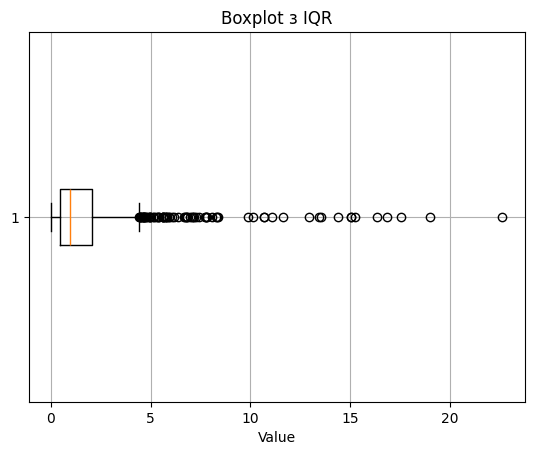

In [20]:
import numpy as np
import matplotlib.pyplot as plt

data = np.random.lognormal(mean=0, sigma=1.0, size=1000)

plt.boxplot(data, vert=False)
plt.title("Boxplot з IQR")
plt.xlabel("Value")
plt.grid(True)
plt.show()

Boxplot наочно показує:

* **Медіану** (середню лінію)
* **Q1, Q3** — краї «коробки»
* **IQR** — ширина коробки
* **вуса** — межі без викидів
* **викиди** — точки поза межами

## Чому IQR важливий аналітикам

| Причина                                              | Пояснення                                            |
| ------------------------------------------------------ | ------------------------------------------------------- |
| Стійкий до викидів                                     | На відміну від дисперсії чи стандартного відхилення  |
| Дає уявлення про "нормальний" діапазон                | Середні 50% — найтиповіші                             |
| Універсальний — працює для будь-яких форм розподілу  | Симетричних, скошених, тощо                          |

---

* **IQR** — один із ключових показників у **EDA (Exploratory Data Analysis)**
* Він дозволяє **оцінити структуру даних**, незалежно від того, чи розподіл нормальний чи ні

## Практика: шукаємо викиди в реальних даних (King County House Sales)

Застосуємо все вище на вже знайомому датасеті продажів житла (King County) — подивимось, скільки об'єктів IQR-правило визначає як викиди за ціною, і що з цим можна зробити.

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/cpython-projects/python_da_17_03_26/refs/heads/main/kc_house_data.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180.0,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170.0,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770.0,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050.0,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680.0,0,1987,0,98074,47.6168,-122.045,1800,7503


Нагадаємо форму розподілу ціни — вона права-скошена (довгий хвіст дорогих будинків), тож саме тут метод IQR буде показовим.

<Axes: >

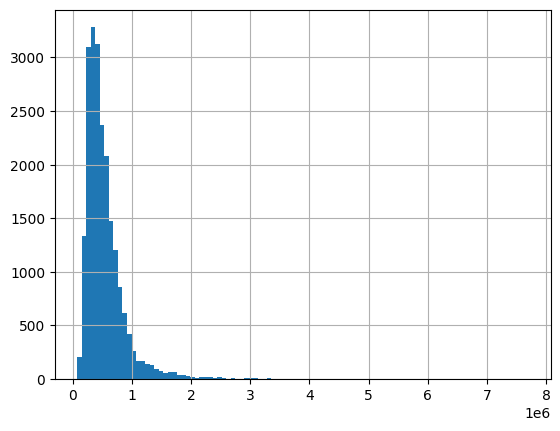

In [ ]:
df.price.hist(bins=100)

In [ ]:
q1 = df.price.quantile(0.25)
q3 = df.price.quantile(0.75)

In [ ]:
q1, q3

(np.float64(321950.0), np.float64(645000.0))

25% будинків коштують дешевше **321 950 $**, а 75% — дешевше **645 000 $**. Порахуємо міжквартильний розмах.

In [ ]:
IQR = q3 - q1

In [ ]:
IQR

np.float64(323050.0)

Тепер за стандартним правилом `Q1 − 1.5·IQR` та `Q3 + 1.5·IQR` знайдемо межі "нормального" діапазону.

In [ ]:
lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR
print(lower, upper)

-162625.0 1129575.0


> ⚠️ **Важливе спостереження.** Нижня межа вийшла **від'ємною** (-162 625 $) — а ціна фізично не може бути від'ємною! Порівняємо з реальним мінімумом у датасеті:

In [ ]:
df.price.min()

75000.0

Реальний мінімум (**75 000 $**) набагато вищий за теоретичну нижню межу, тобто **формула `Q1 − 1.5·IQR` тут не спрацює як "виявник дешевих викидів"** — просто тому, що серед *дешевих* будинків немає таких, що виглядали б аномально дешево відносно решти вибірки. Це нормально для правоскошених даних: IQR-правило на практиці працюватиме лише як фільтр **дорогих** об'єктів (верхня межа), а не дешевих.

Відфільтруємо будинки, дешевші за верхню межу (**1 129 575 $**), і подивимось на розподіл того, що лишилось.

In [ ]:
df_new = df[df.price <= upper]

<Axes: >

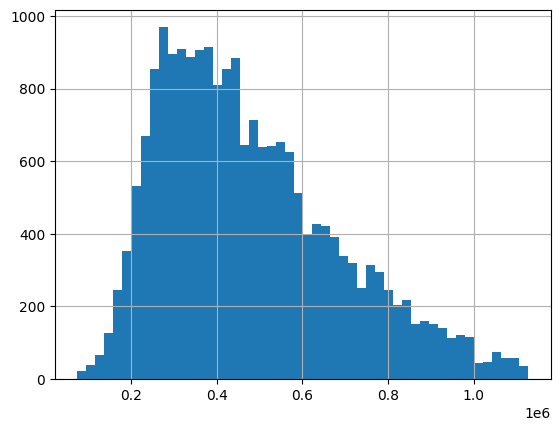

In [ ]:
df_new.price.hist(bins=50)

Розподіл після фільтрації виглядає значно симетричнішим — довгий хвіст справа майже зник. Порахуємо, скільки рядків ми прибрали.

In [ ]:
df.shape

(21613, 21)

In [ ]:
df_new.shape

(20467, 21)

Було **21 613** рядків, стало **20 467** — тобто IQR-правило позначило **1 146 будинків (≈5.3%)** як цінові викиди. Подивимось окремо на них — це і є "відсічений хвіст" розподілу.

In [ ]:
df_2 = df[df.price > upper]

<Axes: >

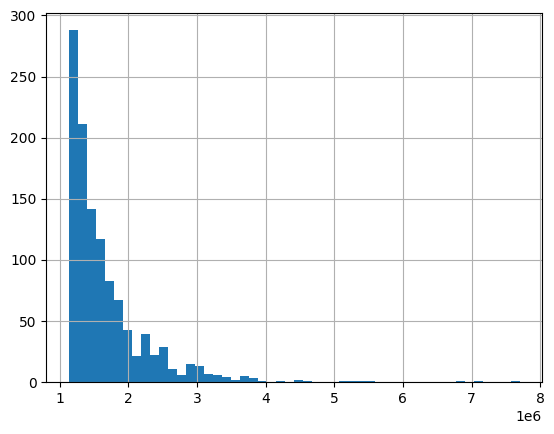

In [ ]:
df_2.price.hist(bins=50)

Це справді окрема група: дорогі й дуже дорогі об'єкти, самі по собі теж право-скошені (є будинки за кілька мільйонів на тлі "типового" мільйона з невеликим хвостиком) — цілком очікувано для елітного сегмента.

## Чи достатньо гістограми? Перевіряємо нормальність формально

Раніше (розділ 4) ми ставили питання: "чи достатньо тільки візуалізації для визначення типу розподілу?" і відповіли — ні, іноді потрібне **формальне статистичне обґрунтування**. Перевіримо це на `price`: гістограма явно показує скошеність, але кількісно наскільки?

**Асиметрія (skewness)** і **ексцес (kurtosis)** — числові міри форми розподілу:

* `skew() ≈ 0` → симетричний розподіл; `skew() > 0` → довгий хвіст справа (право-скошений); `skew() < 0` → хвіст зліва.
* `kurtosis() ≈ 0` (за означенням `scipy`, "excess kurtosis" відносно нормального) → "нормальна" гостровершинність; `> 0` → гостріший пік і важчі хвости, ніж у нормального розподілу.

In [ ]:
print('Асиметрія (skew):', df.price.skew())
print('Ексцес (kurtosis):', df.price.kurt())

Асиметрія (skew): 4.024069144684712
Ексцес (kurtosis): 34.58554043194243


`skew ≈ 4.02` — сильна додатна асиметрія (значно більше "правила великого пальця" |skew| > 1, яке вже вважають істотним скошенням), а `kurtosis ≈ 34.6` — розподіл набагато гостріший і з набагато важчими хвостами, ніж нормальний (де обидва показники були б ≈0). Це кількісно підтверджує те, що ми вже бачили на гістограмі.

### Формальний тест нормальності

`scipy.stats` має готові тести. `normaltest` (тест Д'Агостіно-Пірсона) перевіряє нульову гіпотезу "дані розподілені нормально" — якщо p-value дуже мале (зазвичай < 0.05), гіпотезу відхиляємо.

In [ ]:
from scipy import stats

stat, p_value = stats.normaltest(df.price)
print('statistic =', stat)
print('p-value =', p_value)

statistic = 19121.788941861127
p-value = 0.0


`p-value` виходить практично нульовим (набагато менше 0.05) — тест впевнено відхиляє гіпотезу нормальності. Це формально підтверджує те, що ми й так бачили: `price` **не** розподілена нормально.

> ⚠️ На дуже великих вибірках (тут — 21 613 рядків) такі тести майже завжди "відхиляють нормальність", навіть для незначних відхилень — статистична значущість не те саме, що практична важливість. Тому тест варто читати разом із гістограмою й числами skew/kurtosis, а не замість них.

### QQ-plot: ще один спосіб "побачити" відхилення від нормальності

Quantile-Quantile plot порівнює квантилі наших даних із квантилями теоретичного нормального розподілу: якщо дані нормальні, точки лягають на пряму лінію.

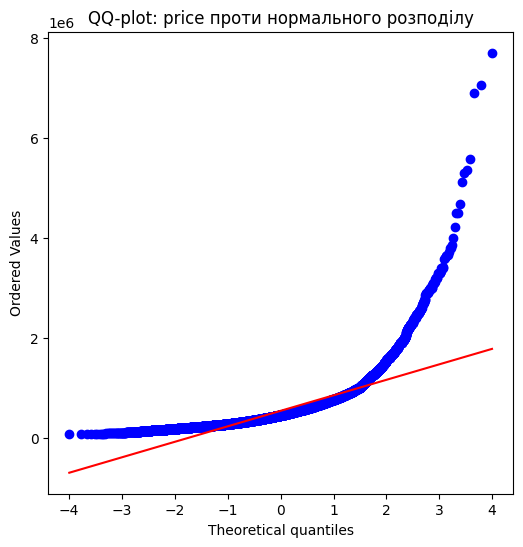

In [ ]:
import matplotlib.pyplot as plt
from scipy import stats

fig = plt.figure(figsize=(6, 6))
stats.probplot(df.price, dist="norm", plot=plt)
plt.title("QQ-plot: price проти нормального розподілу")
plt.show()

Точки різко відхиляються від прямої лінії вгорі (праворуч) — це саме той "важкий правий хвіст", який ми вже бачили на гістограмі й підтвердили через `skew`/`kurtosis`/`normaltest`. Три різні інструменти (гістограма, числові міри, формальний тест і QQ-plot) узгоджено вказують на одне й те саме — це і є хороша практика EDA: не покладатись на єдиний метод.

### Альтернатива відсіканню викидів: лог-трансформація

Замість того, щоб **викидати** 5.3% даних, можна залишити всі спостереження, але прологарифмувати ціну — так само, як робили раніше для логнормального розподілу. Повернемось до повного (нефільтрованого) `df` з усіма цінами.

<Axes: >

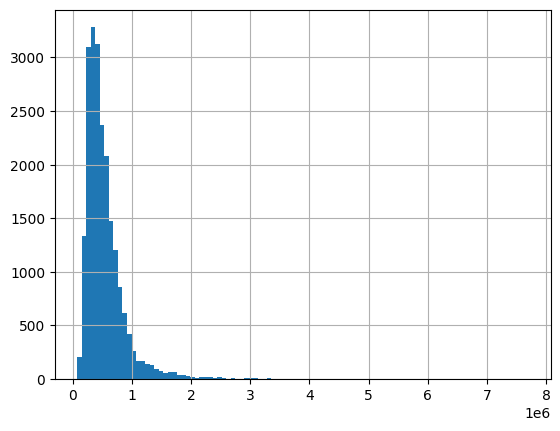

In [ ]:
df.price.hist(bins=100)

`numpy` вже імпортований і використовувався вище — застосуємо `log1p` (тобто `log(1 + x)`, безпечний варіант на випадок нульових цін, хоча тут нулів і немає) до колонки `price`.

In [ ]:
df['log_price'] = np.log1p(df['price'])

<Axes: >

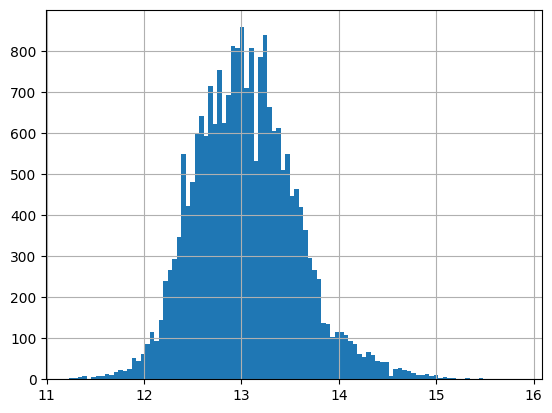

In [ ]:
df.log_price.hist(bins=100)

У логарифмічній шкалі розподіл ціни виглядає значно ближче до нормального (симетричного) — саме той ефект, який ми вже бачили на штучних логнормальних даних раніше в лекції.

Порахуємо середнє в лог-шкалі та переведемо його назад — це і буде **геометричне середнє** ціни.

In [ ]:
price_avg = df.log_price.mean()
price_avg

np.float64(13.0478193715726)

In [ ]:
np.exp(price_avg)

np.float64(464083.31420790055)

Порівняємо три "середніх" значення ціни поруч:

In [ ]:
df.price.mean()

np.float64(540088.1417665294)

In [ ]:
df.price.median()

450000.0

## Як обрати метод: підсумкова схема

Усю лекцію ми користувались різними інструментами по черзі. Зведемо їх в один алгоритм прийняття рішення — саме те, що ми фактично й зробили з `price` вище, тільки тепер явно по кроках.

**Крок 1. Подивись на форму (гістограма + boxplot).** Це завжди перший крок, і часто цього достатньо, щоб відкинути очевидно хибні підходи.

**Крок 2. Якщо форма непевна "на око" (мало даних, тонкі відмінності) — перевір формально.** `skew()`, `kurt()`, `normaltest`, QQ-plot — саме такими інструментами ми підтвердили, що `price` не нормальна (розділ 7), а не просто "здалось на графіку".

**Крок 3. Обери метод за формою:**

| Форма розподілу | Що НЕ варто робити | Що робити | Чому |
|---|---|---|---|
| Симетрична, без важких хвостів (≈нормальна) | — | Середнє, std, правило ±3σ, Z-score | Ці інструменти й побудовані під нормальний розподіл — тут вони коректні |
| Право-скошена, значення завжди додатні, зростають мультиплікативно (ціни, доходи, тривалість) | Рахувати "просто середнє" й довіряти йому | Лог-трансформація (`log1p`) → рахувати статистики в лог-шкалі → повертати через `exp` (геометричне середнє) | Логарифм "випрямляє" мультиплікативну асиметрію в звичайну нормальну форму |
| Скошена, є явні викиди, трансформувати не хочеться / потрібна проста стійка межа | Z-score на малій вибірці з підозрою на сильний викид | Медіана + IQR (`Q1 − 1.5·IQR`, `Q3 + 1.5·IQR`) | IQR рахується через квантилі, які не "тягнуться" за екстремальними значеннями, на відміну від середнього й σ |
| Дискретні лічильники подій (дзвінки/год, покупки/хв) | Застосовувати неперервні правила (±3σ, IQR) не думаючи | Моделювати як Пуассон (або спершу перевірити, чи `mean ≈ variance`, ознака Пуассона) | Це інша природа даних — "кількість подій", а не неперервна величина |
| Мультимодальна (кілька піків) | Рахувати одне загальне середнє/медіану на всю вибірку | Спершу розділити на групи (як `df_econom`/`df_vip`), і рахувати статистики **окремо по кожній** | Одне число для суміші різних груп не описує жодну з них правильно |

**Крок 4. Пам'ятай обмеження методів, а не лише їхні означення:**

* Z-score на малій вибірці з сильним викидом сам себе маскує (розділ 6) — на вибірках до кількох десятків спостережень довіряй йому обережно.
* Формальні тести нормальності (`normaltest`) на дуже великих вибірках майже завжди відхиляють нормальність, навіть для дрібних відхилень — не єдиний аргумент, лише один з кількох.
* IQR-межі можуть виходити фізично неможливими (від'ємна ціна) — це нормально для сильно скошених даних і означає, що правило працює лише "з одного боку".

> Наш приклад із `price`: форма — право-скошена (крок 1) → підтверджено формально `skew≈4.02`, `normaltest p≈0` (крок 2) → обрали і IQR (відсікти 5.3% дорогих об'єктів), і лог-трансформацію (залишити всі дані, але порахувати геометричне середнє) — крок 3, рядок 2 і 3 одночасно, бо це не взаємовиключні підходи, а два різні інструменти для різних задач (перший — "почистити" дані перед моделюванням, другий — "коректно порахувати типове значення", не викидаючи нічого).

## Підсумок

| Поняття | Що показує | Коли використовувати |
|---|---|---|
| Гістограма / boxplot | Форму розподілу | Завжди перший крок EDA |
| Середнє + std, правило 3σ | Центр і розкид **симетричних** даних | Дані близькі до нормальних, без сильних викидів |
| Коефіцієнт варіації (CV) | Відносний розкид (σ/середнє) | Порівняння розкиду між різними шкалами/показниками |
| Z-score | На скільки σ значення відхиляється від середнього | Пошук аномалій у приблизно нормальних даних; обережно з малими вибірками (ефект маскування) |
| Медіана, квантилі, IQR | Стійкий до викидів центр і розкид | Скошені дані, дані з викидами — типова ситуація в бізнесі |
| Лог-трансформація + геометричне середнє | "Випрямляє" мультиплікативно-скошені дані | Ціни, доходи, тривалість — дані, що зростають у відсотках, а не в абсолютних одиницях |

### Завдання для самостійної роботи

1. Порахуйте Z-score для колонки `price` (на всьому датасеті, не на іграшковому прикладі з 7 значень) і подивіться, скільки будинків мають `|Z| > 3`.
2. Порівняйте кількість викидів за Z-score (`|Z| > 3`) і за IQR-правилом. Чи це одні й ті самі об'єкти?
3. Побудуйте boxplot для `price` окремо по кожному значенню `waterfront` (0 і 1). Чи відрізняється IQR?
4. Застосуйте лог-трансформацію до `sqft_living` і порівняйте гістограму до і після.